# Case study for lane merging ![Merging Diagram](merging-scenario.jpg)

In [46]:
import numpy as np
from highway_branch_dyn import *
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import pyplot as plt

In [112]:
v0 = 10
class agent():
    '''
    Double integrater vehile model. State = [x, v]
    '''
    def __init__(self, state=[0, v0], V_length=4, V_width=2.4, dt=0.05, backupidx=0,laneidx=0):
        self.state = state
        self.dt = dt
        self.V_length = V_length
        self.V_width = V_width
        self.V_pred = []
        self.backupidx = backupidx
        self.laneidx = laneidx
    def step(self, u):
        dxdt = np.array([self.state[1], u])
        self.state = self.state + dxdt*self.dt

In [113]:
class merging_env():
    def __init__(self, NA, N_lane, merge_lane=2, lane_width = 3.6, merge_angle=np.radians(10), merge_s=50, dt=0.05):
        self.dt = dt
        self.NA = NA # Number of agent
        self.laneID = [1]+[0]*(NA-1)
        self.N_lane = N_lane
        self.merge_lane = merge_lane
        self.agent_set = []
        self.merge_angle=merge_angle
        self.merge_s = merge_s
        merge_lane_start = np.array([merge_s - merge_s*np.cos(merge_angle), lane_width + np.sin(merge_angle)*merge_s])
        merge_lane_ref_s1 = np.linspace(0, merge_s, num=int(merge_s/0.5), endpoint=False) # Straight portion
        merge_lane_ref_X = merge_lane_start[0] + merge_lane_ref_s1*np.cos(merge_angle)
        merge_lane_ref_Y = merge_lane_start[1] - merge_lane_ref_s1*np.sin(merge_angle)
        merge_lane_ref_psi = -np.ones(merge_lane_ref_s1.shape)*merge_angle
        merge_lane_end = merge_s + lane_width/np.sin(merge_angle)
        self.merge_lane_ref_X = merge_lane_ref_X
        self.merge_lane_ref_Y = merge_lane_ref_Y
        self.merge_lane_ref_psi = merge_lane_ref_psi
        self.merge_lane_start = merge_lane_start
        self.merge_lane_end = merge_lane_end
        self.ref_Y = interpolant('ref_Y', 'linear', [self.merge_lane_ref_X], self.merge_lane_ref_Y)
        self.ref_psi = interpolant('refY','linear',[self.merge_lane_ref_X],self.merge_lane_ref_psi)
        x0 = np.array([[24, v0], [15, v0]])
        for i in range(0, self.NA):
            self.agent_set.append(agent(x0[i],dt=self.dt))
    
    def step(self):
        u_set  = [None]*self.NA # Control input
        xx_set = [None]*self.NA # Predicted state
        u0_set = [None]*self.NA # Backup policies
        x_set  = [None]*self.NA # State

        #self.xbackup = np.empty([0,(self.mpc.N+1)*4])
        for i in range(0,self.NA):
            z = self.agent_set[i].state
            if self.agent_set[i].state[0] > self.merge_s:
                self.laneID[i] = 0
            #xx_set[i] = self.pred_model[self.laneID[i]].zpred_eval(z)

        # idx0 = self.agent_set[0].backupidx
        # n = self.pred_model[self.laneID[0]].n
        # x1 = xx_set[0][:,idx0*n:(idx0+1)*n]

        # for i in range(0, self.NA):
        #     if i != 0:
        #         hi = np.zeros(self.m[self.laneID[i]])
        #         if self.laneID[i] == 0:
        #             for j in range(0, self.m[0]):
        #                 hi[j] = min(np.append(
        #                     veh_col(x1, xx_set[i][:, j * n:(j + 1) * n], [self.cons.L + 1, self.cons.W + 0.2]),
        #                     lane_bdry_h(xx_set[i][:, j * n:(j + 1) * n], self.LB[0], self.LB[1])
        #                 ))
        #         elif self.laneID[i] == 1:
        #             for j in range(0, self.m[1]):
        #                 hi[j] = veh_col(x1, xx_set[i][:, j * n:(j + 1) * n], [self.cons.L + 1, self.cons.W + 0.2])
        #         self.agent_set[i].backupidx = np.argmax(hi)
        #     self.agent_set[i].backupidx = 0
        #     u0_set[i] = self.backupcons[self.laneID[i]][self.agent_set[i].backupidx](self.agent_set[i].state)


        for i in range(0, self.NA):
            u_set[i] = 0
            self.agent_set[i].step(0)
            x_set[i] = self.agent_set[i].state


        return u_set,x_set,xx_set

In [114]:
def Highway_sim(env,T):
    # simulate the scenario
    collision = False
    dt = env.dt
    t=0
    Ts_update = 4
    N_update = int(round(Ts_update/dt))
    N = int(round(T/dt))
    state_rec = np.zeros([env.NA,N,2])
    b_rec = [None]*N
    backup_rec = [None]*env.NA
    backup_choice_rec = [None]*env.NA
    for i in range(0,env.NA):
        backup_rec[i]=[None]*N
        backup_choice_rec[i] = [None]*N
    input_rec = np.zeros([env.NA,N,2])
    f0 = np.array([v0,0,0,0])
    for i in range(0,len(env.agent_set)):
        state_rec[i][t]=env.agent_set[i].state

    xx_set = []
    dis = 100
    while t<N:
        if not collision:
            for i in range(0,env.NA):
                for j in range(0,env.NA):
                    if i!=j:
                        dis = max(abs(env.agent_set[i].state[0]-env.agent_set[j].state[0])-0.5*(env.agent_set[i].V_length+env.agent_set[j].V_length),\
                        abs(env.agent_set[i].state[1]-env.agent_set[j].state[1])-0.5*(env.agent_set[i].V_width+env.agent_set[j].V_width))
                if dis<0:
                    collision = True

        print("t=",t*env.dt)

        u_set,x_set,xx_set=env.step()

        for i in range(0,env.NA):
            input_rec[i][t]=u_set[i]
            state_rec[i][t]=x_set[i]
            backup_rec[i][t]=xx_set[i]
            backup_choice_rec[i][t] = env.agent_set[i].backupidx
        t=t+1
    return state_rec,input_rec,backup_rec,backup_choice_rec,collision

In [115]:


env = merging_env(2, 1)
state_rec,input_rec,backup_rec,backup_choice_rec,collision = Highway_sim(env, 1)

t= 0.0
t= 0.05
t= 0.1
t= 0.15000000000000002
t= 0.2
t= 0.25
t= 0.30000000000000004
t= 0.35000000000000003
t= 0.4
t= 0.45
t= 0.5
t= 0.55
t= 0.6000000000000001
t= 0.65
t= 0.7000000000000001
t= 0.75
t= 0.8
t= 0.8500000000000001
t= 0.9
t= 0.9500000000000001


In [120]:
state_rec

array([[[24.5, 10. ],
        [25. , 10. ],
        [25.5, 10. ],
        [26. , 10. ],
        [26.5, 10. ],
        [27. , 10. ],
        [27.5, 10. ],
        [28. , 10. ],
        [28.5, 10. ],
        [29. , 10. ],
        [29.5, 10. ],
        [30. , 10. ],
        [30.5, 10. ],
        [31. , 10. ],
        [31.5, 10. ],
        [32. , 10. ],
        [32.5, 10. ],
        [33. , 10. ],
        [33.5, 10. ],
        [34. , 10. ]],

       [[15.5, 10. ],
        [16. , 10. ],
        [16.5, 10. ],
        [17. , 10. ],
        [17.5, 10. ],
        [18. , 10. ],
        [18.5, 10. ],
        [19. , 10. ],
        [19.5, 10. ],
        [20. , 10. ],
        [20.5, 10. ],
        [21. , 10. ],
        [21.5, 10. ],
        [22. , 10. ],
        [22.5, 10. ],
        [23. , 10. ],
        [23.5, 10. ],
        [24. , 10. ],
        [24.5, 10. ],
        [25. , 10. ]]])

In [91]:
def plot_snapshot(env, lane_width = 3.6, idx=None,varycolor=True,zpatch=True,arrow = True,legend = True):
    '''
    Ploting a snapshot of the simulation, for debugging
    '''
    lm = np.arange(0,7)*lane_width
    plot_merge = isinstance(env,merging_env)
    if plot_merge:
        fig = plt.figure(figsize=(15,6))
    else:
        fig = plt.figure(figsize=(10,3))
    ax = fig.add_subplot(111)
    ego_idx = 0
    ego_veh = env.agent_set[ego_idx]
    veh_patch = [None]*env.NA
    for i in range(0,env.NA):
        if i==ego_idx:
            veh_patch[i]=plt.Rectangle((ego_veh.state[0]-ego_veh.V_length/2,ego_veh.state[1]-ego_veh.V_width/2), ego_veh.V_length,ego_veh.V_width, fc='r', zorder=0)
        else:
            veh_patch[i]=plt.Rectangle((ego_veh.state[0]-ego_veh.V_length/2,ego_veh.state[1]-ego_veh.V_width/2), ego_veh.V_length,ego_veh.V_width, fc='b', zorder=0)


    ego_y = ego_veh.state[1]
    ego_x = ego_veh.state[0]
    if plot_merge:
        xmin = ego_x-10
        xmax = ego_x+40
        ymin = -5
        ymax = 15
    else:
        xmin = ego_x-10
        xmax = ego_x+40
        ymin = ego_y-5
        ymax = ego_y+10
    try:
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(-ymax,-ymin)
    except:
        pdb.set_trace()
    ts = ax.transData
    for i in range(0,env.NA):
        coords = ts.transform([env.agent_set[i].state[0],-env.agent_set[i].state[1]])
        tr = matplotlib.transforms.Affine2D().rotate_around(coords[0], coords[1], -env.merge_lane_ref_psi[i])
        te= ts + tr
        veh_patch[i].set_xy([env.agent_set[i].state[0]-env.agent_set[i].V_length/2,-env.agent_set[i].state[1]-env.agent_set[i].V_width/2])
        veh_patch[i].set_transform(te)
        ax.add_patch(veh_patch[i])

    colorset = ['tab:blue','tab:orange','tab:green','tab:red','tab:purple','tab:brown','tab:pink','tab:gray','tab:olive','tab:cyan','y','m','c','g']
    # xPred,zPred,uPred,branch_w = env.mpc.BT2array()
    # if idx is None:
    #     idx = range(0,len(zPred))

    # for j in idx:
    #     for k in range(0,xPred[j].shape[0]):
    #         if k%2==1:
    #             if varycolor:
    #                 x_patch = plt.Rectangle((xPred[j][k,0]-env.agent_set[ego_idx].V_length/2,-xPred[j][k,1]-env.agent_set[ego_idx].V_width/2), env.agent_set[ego_idx].V_length,env.agent_set[ego_idx].V_width,ec=colorset[j], fc=colorset[j],alpha=0.2, zorder=0)
    #             else:
    #                 x_patch = plt.Rectangle((xPred[j][k,0]-env.agent_set[ego_idx].V_length/2,-xPred[j][k,1]-env.agent_set[ego_idx].V_width/2), env.agent_set[ego_idx].V_length,env.agent_set[ego_idx].V_width,ec='y', fc='y',alpha=0.2, zorder=0)
    #             coords = ts.transform([xPred[j][k,0],-xPred[j][k,1]])
    #             if arrow:
    #                 arr = ax.arrow(xPred[j][k,0],-xPred[j][k,1],uPred[j][k,0]*np.cos(xPred[j][k,3]),-uPred[j][k,0]*np.sin(xPred[j][k,3]),head_width=0.5,length_includes_head=True)
    #             else:
    #                 arr = None
    #             tr = matplotlib.transforms.Affine2D().rotate_around(coords[0], coords[1], -xPred[j][k,3])
    #             x_patch.set_transform(ts+tr)
    #             ax.add_patch(x_patch)

    # for j in idx:
    #     z_patch = plt.plot(zPred[j][:,0],-zPred[j][:,1],'m--',linewidth = 2)[0]
    #     if zpatch:
    #         for k in range(0,zPred[j].shape[0]):
    #             if k%2==1:
    #                 if varycolor:
    #                     z_patch = plt.Rectangle((zPred[j][k,0]-env.agent_set[1].V_length/2,-zPred[j][k,1]-env.agent_set[1].V_width/2), env.agent_set[1].V_length,env.agent_set[1].V_width,ec=colorset[-1-j], fc=colorset[-1-j],alpha=0.2, zorder=0)
    #                 else:
    #                     z_patch = plt.Rectangle((zPred[j][k,0]-env.agent_set[1].V_length/2,-zPred[j][k,1]-env.agent_set[1].V_width/2), env.agent_set[1].V_length,env.agent_set[1].V_width,ec='c', fc='c',alpha=0.2, zorder=0)
    #                 coords = ts.transform([zPred[j][k,0],-zPred[j][k,1]])
    #                 tr = matplotlib.transforms.Affine2D().rotate_around(coords[0], coords[1], -zPred[j][k,3])
    #                 z_patch.set_transform(ts+tr)
    #                 ax.add_patch(z_patch)
    # if legend:
    #     ax.legend([x_patch,z_patch,arr],['Planned trajectory for ego vehicle','Predicted trajectory for the uncontrolled vehicle','Ego vehicle acceleration'],fontsize=15)
    if plot_merge:
        plt.plot([-10, 1000],[-lm[0], -lm[0]], 'g', linewidth=2)
        for j in range(1, env.N_lane):
            plt.plot([-10, 1000],[-lm[j], -lm[j]],  'g--', linewidth=1)

        plt.plot([-10, env.merge_s],[-lm[env.N_lane], -lm[env.N_lane]],  'g', linewidth=2)
        plt.plot([env.merge_lane_end, 1000],[-lm[env.N_lane], -lm[env.N_lane]],  'g', linewidth=2)

        plt.plot(env.merge_lane_ref_X, -env.merge_lane_ref_Y, 'g', linewidth=2)
        for j in range(1,env.merge_lane):
            plt.plot(env.merge_lane_ref_X, -env.merge_lane_ref_Y-j*lane_width, 'g--', linewidth=1)
        plt.plot(env.merge_lane_ref_X, -env.merge_lane_ref_Y-env.merge_lane*lane_width, 'g', linewidth=2)
    else:
        plt.plot([xmin-50, xmax+50],[-lm[0], -lm[0]], 'g', linewidth=2)
        for j in range(1, env.N_lane):
            plt.plot([xmin-50, xmax+50],[-lm[j], -lm[j]], 'g--', linewidth=1)
        plt.plot([xmin-50, xmax+50],[-lm[env.N_lane], -lm[env.N_lane]], 'g', linewidth=2)
    plt.show()

In [92]:
env.merge_lane_ref_psi

array([-0.17453293, -0.17453293, -0.17453293, -0.17453293, -0.17453293,
       -0.17453293, -0.17453293, -0.17453293, -0.17453293, -0.17453293,
       -0.17453293, -0.17453293, -0.17453293, -0.17453293, -0.17453293,
       -0.17453293, -0.17453293, -0.17453293, -0.17453293, -0.17453293,
       -0.17453293, -0.17453293, -0.17453293, -0.17453293, -0.17453293,
       -0.17453293, -0.17453293, -0.17453293, -0.17453293, -0.17453293,
       -0.17453293, -0.17453293, -0.17453293, -0.17453293, -0.17453293,
       -0.17453293, -0.17453293, -0.17453293, -0.17453293, -0.17453293,
       -0.17453293, -0.17453293, -0.17453293, -0.17453293, -0.17453293,
       -0.17453293, -0.17453293, -0.17453293, -0.17453293, -0.17453293,
       -0.17453293, -0.17453293, -0.17453293, -0.17453293, -0.17453293,
       -0.17453293, -0.17453293, -0.17453293, -0.17453293, -0.17453293,
       -0.17453293, -0.17453293, -0.17453293, -0.17453293, -0.17453293,
       -0.17453293, -0.17453293, -0.17453293, -0.17453293, -0.17

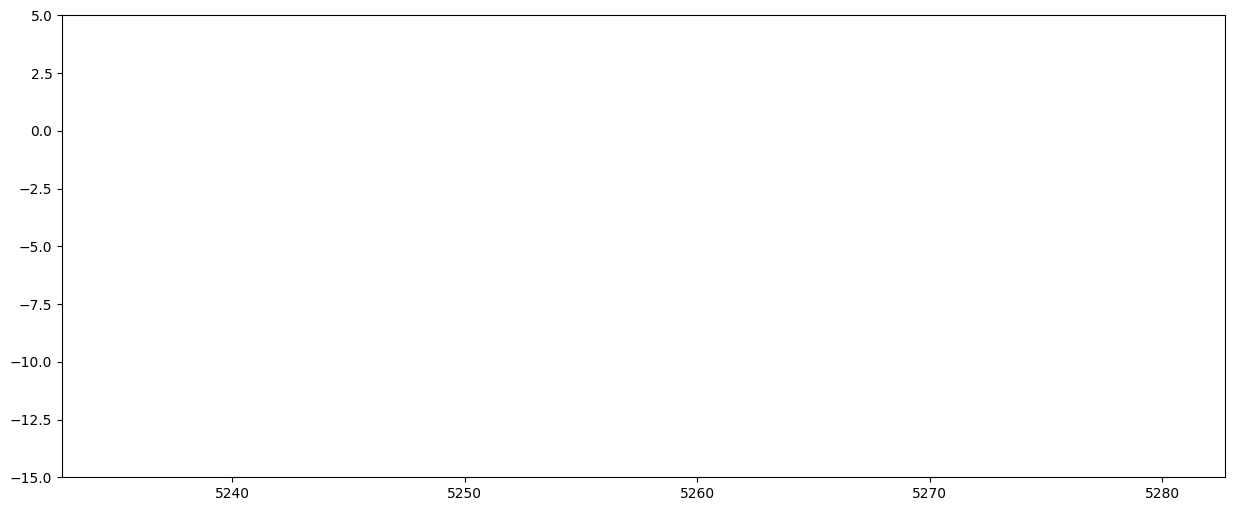

In [93]:
plot_snapshot(env)